# 95662 - Introduction to Machine Learning
##### By: Brenno, Camilla, Kok Soon

## 0. Config and Imports

In [ ]:
import os
from pathlib import Path
import json
import pandas as pd
import random
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import pprint as pp

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: False


In [ ]:
# Fixing seed to remove randomness, for better comparisons
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

### A. Local Setup

In [ ]:
# DATA_DIR = Path('./data')# Path to dataset

### B. Colab Setup

In [ ]:
!pip -q install gdown

DATA_DIR = Path("/content/ML_Exam_Project/data")
DATA_DIR.mkdir(parents=True,exist_ok=True)

MODEL_DIR = Path("/content/ML_Exam_Project/model")
MODEL_DIR.mkdir(parents=True,exist_ok=True)

DATA_FOLDER_URL = "https://drive.google.com/drive/folders/17Cklb8rQ2DJt_NoWPCbgqkd16V1MOXiw?usp=sharing"
MODEL_FOLDER_URL = "https://drive.google.com/drive/folders/1D2treqldEpK5vJJd2twgP2_QmNY6PE1n?usp=sharing"

!gdown --folder "$DATA_FOLDER_URL" -O "$DATA_DIR"
!gdown --folder "$MODEL_FOLDER_URL" -O "$MODEL_DIR"

Retrieving folder contents
Processing file 1mxYncZ-k5CJVcaMHjpEtsp79OSXVrSR2 test_id.jsonl
Processing file 1utlrU9pwh-Ou1LomUKtZXaB6HemPzI9s test_long.jsonl
Processing file 17YHqluGDYL1izzYFYWON5FzDZZaCcist test_ood.jsonl
Processing file 1NdggUzNXe6kDP6PEKQWcBlDtw7kwL0p3 train_augmented_A.jsonl
Processing file 1dAFzAPLSCxrl_5unrqaM5zxhSITvuVfh train_augmented_B.jsonl
Processing file 1G9-aU2gAnKYI6RW2_98uW6DaEN5zvOG- train_augmented_C.jsonl
Processing file 1uZ9iQSPtoYhlb1Kt2jCigoFePQGsgLRb train.jsonl
Processing file 1-rlAgZNxrunxA2S5ZFZS0LZNM_mykdMt validation_augmented_A.jsonl
Processing file 1WzTya6JE7KIzhxezWNWaG9TUzBRTOvHH validation_augmented_B.jsonl
Processing file 1vgD5CflTVA04p6qVnhw5pdsjtZiI_BDe validation_augmented_C.jsonl
Processing file 1knh_LSuwKqZeUn5cbFJ9bfnu03iYQKJ0 validation.jsonl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1mxYncZ-k5CJVcaMHjpEtsp79OSXVrSR2

## 1. Data Loading

### 1.1 File Sanity Check

In [ ]:
expected_files = [
    "train.jsonl",
    "validation.jsonl",
    "test_id.jsonl",
    "test_ood.jsonl",
    "test_long.jsonl",
    "train_augmented_A.jsonl",
    "train_augmented_B.jsonl",
    "train_augmented_C.jsonl",
    "validation_augmented_A.jsonl",
    "validation_augmented_B.jsonl",
    "validation_augmented_C.jsonl"
]

for filename in expected_files:
    path = DATA_DIR / filename
    assert path.exists(), f"Missing file: {path}"

print("All dataset files found:")
for filename in expected_files:
    print(" -", DATA_DIR / filename)

All dataset files found:
 - /content/ML_Exam_Project/data/train.jsonl
 - /content/ML_Exam_Project/data/validation.jsonl
 - /content/ML_Exam_Project/data/test_id.jsonl
 - /content/ML_Exam_Project/data/test_ood.jsonl
 - /content/ML_Exam_Project/data/test_long.jsonl
 - /content/ML_Exam_Project/data/train_augmented_A.jsonl
 - /content/ML_Exam_Project/data/train_augmented_B.jsonl
 - /content/ML_Exam_Project/data/train_augmented_C.jsonl
 - /content/ML_Exam_Project/data/validation_augmented_A.jsonl
 - /content/ML_Exam_Project/data/validation_augmented_B.jsonl
 - /content/ML_Exam_Project/data/validation_augmented_C.jsonl


### 1.2 Data Loading

In [ ]:
# Function to load jsonl into pandas df object
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

In [ ]:
data = {}
for filename in expected_files:
    data[filename.split(".")[0]] = load_jsonl(DATA_DIR / filename)

{'test_id':                  id     expression  value  length  operator_count  depth
0     test_id-00000        1-(1-5)      5       7               2      3
1     test_id-00001        9-(2-6)     13       7               2      3
2     test_id-00002      0+0+5+6-6      5       9               4      4
3     test_id-00003      2-8-(8+8)    -22       9               3      3
4     test_id-00004  9-(5-(5+7-2))     14      13               4      5
...             ...            ...    ...     ...             ...    ...
1995  test_id-01995      1+2+3+3+3     12       9               4      4
1996  test_id-01996    9+5+5+4-4-1     18      11               5      5
1997  test_id-01997  1-(3-8)-(4+3)     -1      13               4      4
1998  test_id-01998          1+2+0      3       5               2      3
1999  test_id-01999    4+0+3-(2-0)      5      11               4      4

[2000 rows x 6 columns],
 'test_long':                    id           expression  value  length  operator_coun

In [ ]:
# Choose what goes into the training and validation (augmented etc.)
combined_train_df = pd.concat([data["train"]], ignore_index=True)
combined_validation_df = pd.concat([data["validation"]], ignore_index=True)

## 2. Data Analysis

### 2.1 Data shapes

In [ ]:
print("Train:", data["train"].shape)
print("Train Augmented A:", data["train_augmented_A"].shape)
print("Train Augmented B:", data["train_augmented_B"].shape)
print("Train Augmented C:", data["train_augmented_C"].shape)
print("Validation:", data["validation"].shape)
print("Validation Augmented A:", data["validation_augmented_A"].shape)
print("Validation Augmented B:", data["validation_augmented_B"].shape)
print("Validation Augmented C:", data["validation_augmented_C"].shape)
print("Test ID:", data["test_id"].shape)
print("Test OOD:", data["test_ood"].shape)
print("Test long:", data["test_long"].shape)

Train: (12000, 6)
Train Augmented A: (36000, 6)
Train Augmented B: (12000, 6)
Train Augmented C: (36000, 6)
Validation: (2000, 6)
Validation Augmented A: (6000, 6)
Validation Augmented B: (2000, 6)
Validation Augmented C: (6000, 6)
Test ID: (2000, 6)
Test OOD: (2000, 6)
Test long: (1500, 6)


### 2.2 Data Example

In [ ]:
data["train"].head()

,id,expression,value,length,operator_count,depth
0,train-00000,4+4+7+3+8-1,25,11,5,5
1,train-00001,5-(6-5)+8+8,20,11,4,5
2,train-00002,5-3+1,3,5,2,3
3,train-00003,1-(1+5+8+7+1),-21,13,5,6
4,train-00004,7+1-(6+5+9),-12,11,4,4


### 2.3 Test for White Space

It is important to test for white spaces to know if it is required to strip them away because whitespaces such as (1 + 1 3) is a wrong mathematical expression. Furthermore, our plan to use a binary tree to linearize mathematical expression may run into issues if we use whitespace to separate terms

In [ ]:
def check_for_whitespace(dataframes):
    if isinstance(dataframes, pd.DataFrame):
        dfs = [dataframes]
    else:
        dfs = dataframes

    for i, df in enumerate(dfs, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Element {i} is not a DataFrame")

    combined_df = pd.concat(dfs, ignore_index=True)

    return combined_df["expression"].astype(str).str.contains(r"\s").any()

In [ ]:
print("White Space Exist") if check_for_whitespace(data.values()) else print("No Whitespace found")

No Whitespace found


### 2.4 Test for Unary Operators

Unary operators like -5 have to be considered when constructing expression trees, if unary operators exist, we have to preprocess our data in a way where the sign and the number are interpreted as one (i.e. "-5" instead of "- 5")

In [ ]:
def check_for_unary_operators(dataframes):
    if isinstance(dataframes, pd.DataFrame):
        dfs = [dataframes]
    else:
        dfs = dataframes

    for i, df in enumerate(dfs, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Element {i} is not a DataFrame")

    combined_df = pd.concat(dfs, ignore_index=True)

    def has_unary(expr):
        expr = str(expr)

        for i, ch in enumerate(expr):
            if ch in "+-":
                if i == 0:
                    return True
                if expr[i - 1] in "(-+":
                    return True
        return False

    return combined_df["expression"].apply(has_unary).any()

In [ ]:
print("Unary Operator Exist") if check_for_unary_operators(data.values()) else print("No Unary Operator found")

No Unary Operator found


### 2.5 Tokenization

In [ ]:
PAD_TOKEN = "[PAD]"
VOCABULARY = None # Built Dynamically
VOCAB_SIZE = 0

def tokenize(expression_list):
    global VOCABULARY, PAD_TOKEN

    all_chars = set()
    for expression in expression_list:
        for char in expression:
            all_chars.add(char)

    VOCABULARY = sorted(list(all_chars))
    VOCABULARY = [PAD_TOKEN] + VOCABULARY + [" "]
    token_to_index = {token: i for i, token in enumerate(VOCABULARY)}

    return token_to_index

token_to_index = tokenize(data["train"]["expression"].to_list())
print(token_to_index)

VOCAB_SIZE =len(VOCABULARY)

{'[PAD]': 0, '(': 1, ')': 2, '+': 3, '-': 4, '0': 5, '1': 6, '2': 7, '3': 8, '4': 9, '5': 10, '6': 11, '7': 12, '8': 13, '9': 14, ' ': 15}


In [ ]:
def encode(expression):
    return [token_to_index[token] for token in list(expression)]

def decode(indices):
    return ''.join([VOCABULARY[index] for index in indices if VOCABULARY[index] != PAD_TOKEN])

# Verify that index encoding is working as intended
print(encode('+'))
print(decode(encode('+')))

[3]
+


### 2.6 Data Preprocessing and Transformation

In this step, we aim to represent our input data in a different form in an attempt to help our models learn better

#### 2.6.1 ExpressionTree, Prefix, Postfix

In [ ]:
# Node Structure (Intermediary structure required to build trees)
class Node:
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

In [ ]:
# ExpressionTree Class (class used to represent mathematical expression)
class ExpressionTree:
    def __init__(self, root_node):
        self.root_node = root_node

    def get_root_node(self):
        return self.root_node

    def to_postfix(self):
        def dfs(node):
            if node is None:
                return []
            return dfs(node.left) + dfs(node.right) + [str(node.value)]

        return " ".join(dfs(self.root_node))

    def to_prefix(self):
        def dfs(node):
            if node is None:
                return []
            return [str(node.value)] + dfs(node.left) + dfs(node.right)

        return " ".join(dfs(self.root_node))

    def get_depth(self):
        def dfs(node, current_depth):
            if node is None:
                return current_depth - 1

            left_depth = dfs(node.left, current_depth + 1)
            right_depth = dfs(node.right, current_depth + 1)

            return max(left_depth, right_depth)

        if self.root_node is None:
            return 0

        return dfs(self.root_node, 1)

    def get_operator_count(self):
        operators = "+-"

        def dfs(node):
            if node is None:
                return 0

            count = 1 if str(node.value) in operators else 0

            count += dfs(node.left)
            count += dfs(node.right)

            return count

        return dfs(self.root_node)

In [ ]:
def reduce(operator_stack, operand_stack):
    op = operator_stack.pop()

    right = operand_stack.pop()
    left = operand_stack.pop()

    operand_stack.append(Node(op, left, right))


def build_tree_with_expression(expression):
    subtree_stack = []
    operator_stack = []

    for ch in expression:

        if ch.isnumeric():
            subtree_stack.append(Node(ch))

        elif ch == '(':
            operator_stack.append(ch)

        elif ch == ')':
            while operator_stack[-1] != '(':
                reduce(operator_stack, subtree_stack)

            operator_stack.pop()  # remove '('

        elif ch in '+-':

            while (
                operator_stack
                and operator_stack[-1] != '('
            ):
                reduce(operator_stack, subtree_stack)

            operator_stack.append(ch)

    while operator_stack:
        reduce(operator_stack, subtree_stack)

    root = subtree_stack.pop()
    return ExpressionTree(root)

expression = "5-(6-5)+8+8"
build_tree_with_expression(expression).to_postfix()

'5 6 5 - - 8 + 8 +'

#### 2.6.2 Target Value Normalization
Normalizing the target variable (output) can help improve model performance and stability during training, especially with regression tasks. By scaling the target values, the model can learn more efficiently. We will normalize `y_train` and `y_val` using the mean and standard deviation calculated from `y_train`.

In [ ]:
# Calculate mean and standard deviation from training targets
y_mean = data["train"]["value"].mean()
y_std = data["train"]["value"].std()

print(f"Training target mean: {y_mean:.2f}")
print(f"Training target standard deviation: {y_std:.2f}")

Training target mean: 4.86
Training target standard deviation: 10.59


In [ ]:
def normalize_target_value(value,mean,std):
    return (value - mean) / std

def denormalize_target_value(normalized_value, mean, std):
    return normalized_value * std + mean

### 2.7 Applying Transformations

In this step, we apply the previously discussed preprocessing steps

In [ ]:
def apply_transformation(df):
    df["normalized_value"] = df["value"].apply(lambda y: normalize_target_value(y, y_mean, y_std))
    df["prefix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_prefix())
    df["postfix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_postfix())

    return df

In [ ]:
for data_split, df in data.items():
    data[data_split] = apply_transformation(df)


data['train'].head()

,id,expression,value,length,operator_count,depth,normalized_value,prefix,postfix
0,train-00000,4+4+7+3+8-1,25,11,5,5,1.901590,- + + + + 4 4 7 3 8 1,4 4 + 7 + 3 + 8 + 1 -
1,train-00001,5-(6-5)+8+8,20,11,4,5,1.429479,+ + - 5 - 6 5 8 8,5 6 5 - - 8 + 8 +
2,train-00002,5-3+1,3,5,2,3,-0.175696,+ - 5 3 1,5 3 - 1 +
3,train-00003,1-(1+5+8+7+1),-21,13,5,6,-2.441825,- 1 + + + + 1 5 8 7 1,1 1 5 + 8 + 7 + 1 + -
4,train-00004,7+1-(6+5+9),-12,11,4,4,-1.592027,- + 7 1 + + 6 5 9,7 1 + 6 5 + 9 + -


### 2.8 Summary of Data

Here, we create a function to give a summary of our data so we can compare the different data splits

In [ ]:
# Function to return summary of data
# It is possible to calculate the summary of multiple data split together by passing them in together
def summary(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    result = pd.DataFrame({
        "mean": combined_df.mean(numeric_only=True),
        "std": combined_df.std(numeric_only=True),
        "min": combined_df.min(numeric_only=True),
        "max": combined_df.max(numeric_only=True),

    })

    # Expecting comparison of data split with different size, so we have to normalise for more meaningful comparison
    result.loc["value", "positive_ratio"] = (combined_df["value"] > 0).mean()
    result.loc["value", "negative_ratio"] = (combined_df["value"] < 0).mean()
    result.loc["value", "zero_ratio"] = (combined_df["value"] == 0).mean()

    mode = combined_df.mode(numeric_only=True).iloc[0]
    result["mode"] = mode

    return result

In [ ]:
for split_name,df in data.items():
    display(summary(df).style.set_caption(f"{split_name}"))
    print("\n\n\n")

,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.860750,10.590745,-36.000000,46.000000,0.657250,0.306167,0.036583,2.000000
length,9.607000,3.184713,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.489917,1.116319,2.000000,5.000000,nan,nan,nan,4.000000
depth,3.689917,0.736870,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,0.000000,1.000000,-3.858156,3.884453,nan,nan,nan,-0.270118


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.585000,10.718219,-32.000000,47.000000,0.640000,0.323000,0.037000,4.000000
length,9.604000,3.179975,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.497000,1.115174,2.000000,5.000000,nan,nan,nan,3.000000
depth,3.679000,0.733640,3.000000,6.000000,nan,nan,nan,3.000000
normalized_value,-0.026037,1.012036,-3.480468,3.978875,nan,nan,nan,-0.081274


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,5.232500,10.638516,-29.000000,40.000000,0.668000,0.296000,0.036000,8.000000
length,9.609000,3.239192,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.487000,1.134669,2.000000,5.000000,nan,nan,nan,2.000000
depth,3.722000,0.780398,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,0.035101,1.004511,-3.197202,3.317921,nan,nan,nan,0.296414


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.855500,12.016190,-38.000000,44.000000,0.638000,0.332000,0.030000,5.000000
length,12.484000,3.562596,7.000000,23.000000,nan,nan,nan,9.000000
operator_count,4.515500,1.109223,3.000000,6.000000,nan,nan,nan,5.000000
depth,4.434500,1.058428,3.000000,7.000000,nan,nan,nan,4.000000
normalized_value,-0.000496,1.134593,-4.047001,3.695609,nan,nan,nan,0.013148


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.024667,13.545271,-42.000000,51.000000,0.609333,0.362000,0.028667,7.000000
length,17.744000,2.593379,15.000000,27.000000,nan,nan,nan,15.000000
operator_count,6.214667,0.760463,5.000000,7.000000,nan,nan,nan,7.000000
depth,5.500667,1.413034,4.000000,8.000000,nan,nan,nan,4.000000
normalized_value,-0.078945,1.278973,-4.424689,4.356563,nan,nan,nan,0.201992


...

,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,3.349417,12.794275,-45.000000,46.000000,0.596000,0.374750,0.029250,9.000000
length,17.629333,2.912498,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.936667,1.474959,3.000000,9.000000,nan,nan,nan,7.000000
depth,6.803750,1.550786,4.000000,10.000000,nan,nan,nan,7.000000
normalized_value,-0.142703,1.208062,-4.707955,3.884453,nan,nan,nan,0.390837


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,7.535917,13.212616,-45.000000,60.000000,0.700333,0.274389,0.025278,6.000000
length,16.889056,3.731245,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.739222,1.743965,3.000000,10.000000,nan,nan,nan,5.000000
depth,6.474306,1.724893,4.000000,11.000000,nan,nan,nan,7.000000
normalized_value,0.252595,1.247563,-4.707955,5.206362,nan,nan,nan,0.107570


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.757833,10.404161,-32.000000,49.000000,0.661167,0.301500,0.037333,7.000000
length,9.604000,3.179445,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.497000,1.114988,2.000000,5.000000,nan,nan,nan,3.000000
depth,4.005000,0.930118,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,-0.009718,0.982382,-3.480468,4.167719,nan,nan,nan,0.201992


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,7.228500,19.861937,-52.000000,65.000000,0.635500,0.343000,0.021500,7.000000
length,17.096000,3.206856,11.000000,21.000000,nan,nan,nan,21.000000
operator_count,6.918500,1.631622,3.000000,9.000000,nan,nan,nan,9.000000
depth,6.857500,1.813791,4.000000,10.000000,nan,nan,nan,7.000000
normalized_value,0.223568,1.875405,-5.368910,5.678472,nan,nan,nan,0.201992


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,2.362167,12.558276,-47.000000,49.000000,0.568167,0.400167,0.031667,1.000000
length,16.718000,3.650027,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.729500,1.807265,3.000000,9.000000,nan,nan,nan,9.000000
depth,6.652333,1.895361,4.000000,10.000000,nan,nan,nan,5.000000
normalized_value,-0.235921,1.185778,-4.896799,4.167719,nan,nan,nan,-0.364540


## 3. Helper Functions

### 3.1 Tensor to List
This function is necessary as some libraries do not support gpu

In [ ]:
def tensors_to_list(x):
    return [i.detach().cpu().item() if torch.is_tensor(i) else i for i in x]

### 3.2 Draw Loss Graph

In [ ]:
def draw_loss_graph(epochs, train_losses, val_losses = None, val_losses_RMSE=None, val_losses_MAE=None):     #for the real training if we want to plot we don't have a validation set
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    if val_losses is not None:
        plt.plot(epochs, tensors_to_list(val_losses), label="Validation Loss", marker='o')       #useful for seeing eventual overfitting
        plt.plot(epochs, tensors_to_list(val_losses_RMSE), label="Root Mean Squared Error on the validation set", marker='o')
        plt.plot(epochs, tensors_to_list(val_losses_MAE), label="Mean Absolute Error on the validation set", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Losses")
    plt.legend()
    plt.title("Loss Graph")

### 3.3 Saving and Loading

Kok’s original save function is kept commented below as reference.  
I slightly extended it because saving only the model weights is usually not enough if we want to load the CNN in another notebook.

When we reload the model somewhere else, we need to rebuild it with exactly the same settings used during training: same vocabulary size, same token mapping, same padding token, same model architecture, and same target normalization values.  
If any of these are missing or different, the model might either fail to load or, even worse, load successfully but produce inconsistent predictions.

For this reason, this checkpoint saves not only `model.state_dict()`, but also:
- the optimizer state, so training can be resumed if needed;
- the epoch number;
- the validation loss / metrics;
- the model configuration;
- the vocabulary and token-to-index mapping;
- the padding token;
- the normalization values used for the target variable.

Also, since we noticed possible overfitting, the idea is to save the **best validation checkpoint**, not necessarily the final epoch.  
The final epoch can have a lower training loss, but worse validation performance. Saving the best validation model should make the file more reliable for later testing or for loading it into another notebook.

In [ ]:
def save_cnn_checkpoint(model, optimizer, epoch, path, loss=None, extra=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    checkpoint = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "epoch": epoch,
        "loss": loss,
        "model_config": {
            "vocab_size": VOCAB_SIZE,
            "hidden_channels": 128,
            "num_outputs": 1,
        },
        "token_to_index": token_to_index,
        "V": VOCABULARY,
        "pad_token": PAD_TOKEN,
        "y_mean": float(y_mean),
        "y_std": float(y_std),
    }

    if extra is not None:
        checkpoint.update(extra)

    torch.save(checkpoint, path)
    print(f"Checkpoint saved to: {path}")


def load_cnn_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = ExpressionCNNOneHot(**checkpoint["model_config"]).to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    return model, checkpoint

### 3.4 CNN Full Evaluation

In [ ]:
def cnn_full_evaluation(model,data,normalized_training):
    # Defining Columns
    x_col = "expression"
    y_col = "normalized_value" if normalized_training else "value"


    # Create DataLoader for each data split
    train_dataset = list(zip(data["train"][x_col], data["train"][y_col]))
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    val_dataset = list(zip(data["validation"][x_col], data["validation"][y_col]))
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    test_id_dataset = list(zip(data["test_id"][x_col], data["test_id"][y_col]))
    test_id_loader = torch.utils.data.DataLoader(test_id_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    test_ood_dataset = list(zip(data["test_ood"][x_col], data["test_ood"][y_col]))
    test_ood_loader = torch.utils.data.DataLoader(test_ood_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    test_long_dataset = list(zip(data["test_long"][x_col], data["test_long"][y_col]))
    test_long_loader = torch.utils.data.DataLoader(test_long_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    # Evaluate using the created DataLoaders
    _, RMSE_train, MAE_train, correct_train = evaluate(model, train_loader, DEVICE, normalized_training = normalized_training)
    _, RMSE_val, MAE_val, correct_val = evaluate(model, val_loader, DEVICE, normalized_training = normalized_training)
    _, RMSE_id, MAE_id, correct_id = evaluate(model, test_id_loader, DEVICE, normalized_training = normalized_training)
    _, RMSE_ood, MAE_ood, correct_ood = evaluate(model, test_ood_loader, DEVICE, normalized_training = normalized_training)
    _, RMSE_long, MAE_long, correct_long = evaluate(model, test_long_loader, DEVICE, normalized_training = normalized_training)

    print(f"Train RMSE: {RMSE_train:.4f}, MAE: {MAE_train:.4f}, Correct Matches: {correct_train} ({correct_train/len(data["train"]["expression"]) * 100} %)")
    print(f"Validation RMSE: {RMSE_val:.4f}, MAE: {MAE_val:.4f}, Correct Matches: {correct_val} ({correct_val/len(data["validation"]["expression"]) * 100} %)")
    print(f"Test ID RMSE: {RMSE_id:.4f}, MAE: {MAE_id:.4f}, Correct Matches: {correct_id} ({correct_id/len(data["test_id"]['expression']) * 100} %)")
    print(f"Test OOD RMSE: {RMSE_ood:.4f}, MAE: {MAE_ood:.4f}, Correct Matches: {correct_ood} ({correct_ood/len(data["test_ood"]['expression']) * 100} %)")
    print(f"Test Long RMSE: {RMSE_long:.4f}, MAE: {MAE_long:.4f}, Correct Matches: {correct_long} ({correct_long/len(data["test_long"]['expression']) * 100} %)")

## 4. CNN Regression

### 4.1 Defining Input and Target (x and y)

In [ ]:
combined_train_df = pd.concat([data["train"]], axis=0, ignore_index=True)
combined_validation_df = pd.concat([data["validation"]], axis=0, ignore_index=True)

In [ ]:
x_train = combined_train_df["expression"]
y_train = combined_train_df["value"]
x_val = combined_validation_df["expression"]
y_val = combined_validation_df["value"]

### 4.3 Batching and Transformation

We dynamically pad every batch that has to be given to the nn by the length of the maximum element in it. `batch` is a list of `(input_sequence, target_value)` tuples. For us, `input_sequence` is `x_data`, and `target_value` is `y_data`

In [ ]:
def collate_fn(batch):
    # Separate inputs (expressions) and targets (values)
    expressions = [item[0] for item in batch]
    values = [item[1] for item in batch]

    # Encode expressions
    encoded_expressions = [encode(expr) for expr in expressions]

    # Find the maximum length in the current batch
    batch_max_length = max(len(seq) for seq in encoded_expressions)

    # Pad each sequence in the batch to batch_max_length
    padded_expressions = []
    for seq in encoded_expressions:
        padding_needed = batch_max_length - len(seq)
        padded_seq = seq + [token_to_index[PAD_TOKEN]] * padding_needed
        padded_expressions.append(padded_seq)

    # Convert to PyTorch tensors
    x_batch = torch.tensor(padded_expressions, dtype=torch.long)
    y_batch = torch.tensor(values, dtype=torch.float)

    return x_batch, y_batch

### 4.4 Model Definition

In [ ]:
NUM_OUTPUTS = 1 # For regression, we predict a single value (the result of the expression)

In [ ]:
class ExpressionCNNOneHot(nn.Module):
    def __init__(self, vocab_size, hidden_channels=64, num_outputs=1,dropout=0.0):
        super(ExpressionCNNOneHot, self).__init__()

        # Convolution Layers
        self.conv1 = nn.Conv1d(
            in_channels=vocab_size,
            out_channels=hidden_channels,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            kernel_size=7,
            padding=3
        )

        self.conv3 = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            kernel_size=7,
            padding=3
        )

        self.conv4 = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=hidden_channels//2,
            kernel_size=5,
            padding=2
        )

        # Dropout layers
        self.dropout_conv = nn.Dropout(p=dropout)
        self.dropout_fc = nn.Dropout(p=dropout)

        self.fc = nn.Linear(hidden_channels, num_outputs)

    def forward(self, x, mask):
        h = F.relu(self.conv1(x))
        h = self.dropout_conv(h)

        h = F.relu(self.conv2(h))
        h = self.dropout_conv(h)

        h = F.relu(self.conv3(h))
        h = self.dropout_conv(h)

        h = F.relu(self.conv4(h))
        h = self.dropout_conv(h)

        mask = mask.unsqueeze(1)
        h = h * mask

        lengths = mask.sum(dim=2).clamp(min=1)

        #Pooling
        mean_pool = h.sum(dim=2) / lengths
        max_pool = h.max(dim=2).values
        pooled = torch.cat([mean_pool, max_pool], dim=1)
        pooled = self.dropout_fc(pooled)

        output = self.fc(pooled).squeeze(1)
        return output

In [ ]:
cnn_baseline_model = ExpressionCNNOneHot(
    vocab_size=VOCAB_SIZE,
    hidden_channels=128,
    num_outputs=1,
    dropout=0.0
)

### 4.5 Training

#### 4.5.1 Train Function

In [ ]:
def train(model,
          x_train_data,
          y_train_data,
          optimizer,
          loss_fn,
          normalized_coefficient,
          epochs,
          device,
          batch_size,
          normalized_training = False,
          x_val_data=None,
          y_val_data=None,
          patience = 20,
          min_delta=0.005,
          verbose=True,
          show_loss_graph=True):

    model.to(device)
    train_dataset = list(zip(x_train_data, y_train_data))

    # Dataloaders
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_dataset = list(zip(x_val_data, y_val_data))
    val_dataset_len = len(val_dataset)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    # Dynamic learning rate reduction
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=round(patience * 0.5),
        threshold=min_delta,
        threshold_mode='abs',
    )

    # Flags and Logs
    train_losses = []
    val_losses = []
    val_losses_RMSE = []
    val_losses_MAE = []
    exact_match_accuracies = []
    best_monitor_value = float('inf')
    epochs_without_improvement = 0


    #Best Model Stats
    best_model = {"best_model_state":None,
                  "best_epoch": None,
                  "best_model_accuracy": 0.0,
                  "best_model_loss": float('inf'),
                  "best_model_RMSE": float('inf'),
                  "best_model_MAE": float('inf')}

    for epoch in range(epochs):
        model.train()
        losses = []
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask = (x_batch != token_to_index[PAD_TOKEN]).float()

            # One-hot encode x_batch and permute for conv1d
            x_batch = F.one_hot(x_batch, num_classes=VOCAB_SIZE).float().permute(0, 2, 1)

            optimizer.zero_grad()
            y_pred = model(x_batch, mask)


            loss = loss_fn(y_pred, y_batch) + normalized_coefficient/2 * torch.norm(model.fc.weight, p=2)**2
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        # Validation
        val_loss, RMSE_loss, MAE_loss, correct_matches = evaluate(model, val_loader, device, normalized_training)
        exact_match_accuracy = (correct_matches / val_dataset_len) * 100
        val_losses.append(val_loss)
        val_losses_RMSE.append(RMSE_loss)
        val_losses_MAE.append(MAE_loss)
        exact_match_accuracies.append(exact_match_accuracy)

        # Convert validation metrics from tensors to Python floats.
        # This makes comparisons, logging, and checkpoint selection safer and cleaner.
        val_loss_value = val_loss.item()
        rmse_value = RMSE_loss.item()
        mae_value = MAE_loss.item()

        # Update
        previous_best = best_monitor_value

        # Save the best checkpoint whenever validation improves at all.
        if val_loss_value < best_monitor_value:
            best_monitor_value = val_loss_value

            best_model["best_model_state"] = copy.deepcopy(model.state_dict())
            best_model["best_epoch"] = epoch + 1
            best_model["best_model_accuracy"] = exact_match_accuracy
            best_model["best_model_loss"] = val_loss_value
            best_model["best_model_RMSE"] = rmse_value
            best_model["best_model_MAE"] = mae_value

        # Reset patience when improvement is over a threshold
        if val_loss_value < previous_best - min_delta:
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered. No meaningful improvement in Validation Loss for {patience} epochs.")
            if show_loss_graph:
              draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
              plt.show()
              plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
              plt.title('Exact match accuracy in percentage vs epoch')
              plt.xlabel('epochs')
              plt.ylabel('exact match accuracy (%)')
              plt.show()


            # Reload the best validation checkpoint before returning.
            # This ensures that future evaluations use the best model selected on validation,
            # not simply the model from the last training epoch.
            if best_model["best_model_state"] is not None:
                model.load_state_dict(best_model["best_model_state"])
                print(f"Reloaded best validation checkpoint from epoch {best_model['best_epoch']}")
            return best_model

        if verbose:
            print(f"--- Epoch {epoch+1} ---")
            print(f'Train Loss: {train_loss:.8f}')
            print(f'Validation Loss: {val_loss:.4f}')
            print(f'RMSE Loss on the validation set: {RMSE_loss:.4f}')
            print(f'MAE Loss on the validation set: {MAE_loss:.4f}')
            print(f'Correct predictions on the validation set: {correct_matches:.0f} / {val_dataset_len} ({exact_match_accuracy:.2f}%)')
            print('')

        print('')
        print(scheduler.get_last_lr())
        print('')
        # The scheduler follows the same metric used for early stopping.
        # If this metric reaches a plateau, the learning rate is reduced automatically.
        scheduler.step(val_loss_value)

    if show_loss_graph:
      draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
      plt.show()
      plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
      plt.title('Exact match accuracy in percentage vs epoch')
      plt.xlabel('epochs')
      plt.ylabel('exact match accuracy (%)')
      plt.show()


        # Reload the best validation checkpoint also when training finishes without early stopping.
    # This keeps the model in memory aligned with the checkpoint selected by validation loss.
    if best_model["best_model_state"] is not None:
        model.load_state_dict(best_model["best_model_state"])
        print(f"Reloaded best validation checkpoint from epoch {best_model['best_epoch']}")
    return best_model


def evaluate(model, loader, device, normalized_training=False):
    model.to(device)
    model.eval()
    RMSE_loss = 0
    MAE_loss = 0
    num_samples = 0
    total_loss = 0
    loss_fn_1 = nn.MSELoss()              #for the RMSE
    loss_fn_2 = nn.L1Loss()               #for the MAE
    correct_matches = 0


    with torch.no_grad():
        for batch_size, (x_batch, y_batch) in enumerate(loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask = (x_batch != token_to_index[PAD_TOKEN]).float()

            # One-hot encode x_batch and permute for conv1d
            x_batch = F.one_hot(x_batch, num_classes=VOCAB_SIZE).float().permute(0, 2, 1)

            y_pred = model(x_batch, mask)
            if normalized_training:
              y_pred = denormalize_target_value(y_pred, y_mean, y_std)          #denormalizing the targets for the validation process, useful for exact math accuracy etc...
              y_batch = denormalize_target_value(y_batch, y_mean, y_std)
            for j in range(len(y_pred)):
              RMSE_loss += loss_fn_1(y_pred[j], y_batch[j])
              MAE_loss += loss_fn_2(y_pred[j], y_batch[j])
              pred_rounded = torch.round(y_pred[j]).item()
              target_rounded = torch.round(y_batch[j]).item()

              if pred_rounded == target_rounded:
                correct_matches += 1
            num_samples += x_batch.shape[0]

    average_loss = RMSE_loss / num_samples
    RMSE_loss = torch.sqrt(RMSE_loss / num_samples)
    MAE_loss = MAE_loss / num_samples

    return average_loss, RMSE_loss, MAE_loss, correct_matches

#### 4.5.2 Hyperparameters, Loss Function and Optimizer

In [ ]:
# Training Hyperparameters
batch_size = 32
learning_rate = 0.001
epochs = 1000
normalized_term = 0.005

In [ ]:
loss_fn = nn.MSELoss()

In [ ]:
optimizer = torch.optim.Adam(cnn_baseline_model.parameters(), lr = learning_rate)

#### 4.5.3 Train Loop

--- Epoch 1 ---
Train Loss: 39.73519567
Validation Loss: 13.9581
RMSE Loss on the validation set: 3.7361
MAE Loss on the validation set: 2.7693
Correct predictions on the validation set: 233 / 2000 (11.65%)


[0.001]

--- Epoch 2 ---
Train Loss: 5.97986670
Validation Loss: 3.0417
RMSE Loss on the validation set: 1.7441
MAE Loss on the validation set: 0.9381
Correct predictions on the validation set: 927 / 2000 (46.35%)


[0.001]

--- Epoch 3 ---
Train Loss: 2.11564441
Validation Loss: 1.4547
RMSE Loss on the validation set: 1.2061
MAE Loss on the validation set: 0.7036
Correct predictions on the validation set: 1054 / 2000 (52.70%)


[0.001]

--- Epoch 4 ---
Train Loss: 1.03412493
Validation Loss: 1.0909
RMSE Loss on the validation set: 1.0445
MAE Loss on the validation set: 0.7407
Correct predictions on the validation set: 818 / 2000 (40.90%)


[0.001]

--- Epoch 5 ---
Train Loss: 0.73914598
Validation Loss: 0.6734
RMSE Loss on the validation set: 0.8206
MAE Loss on the validation set

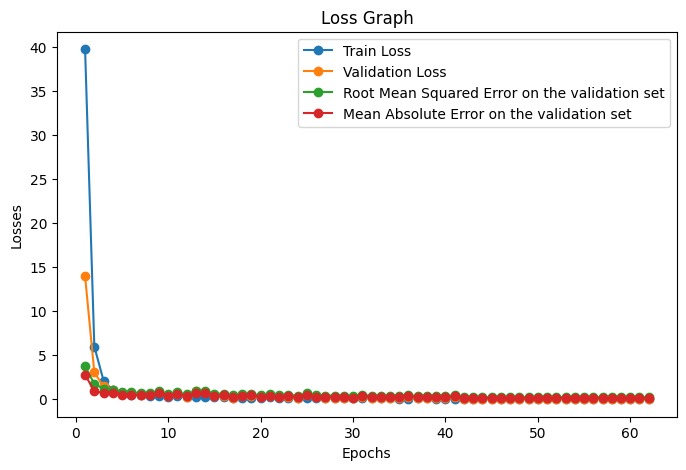

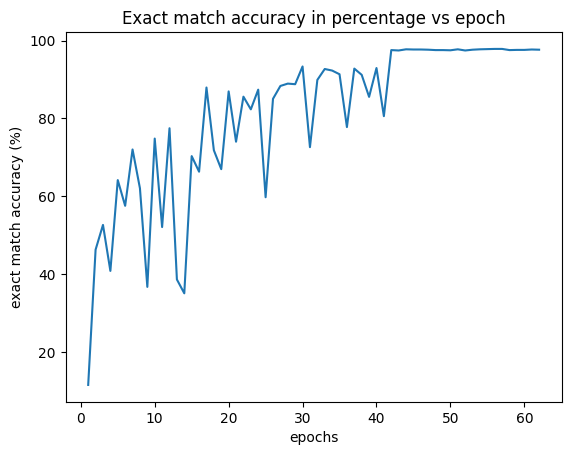

Reloaded best validation checkpoint from epoch 60


In [ ]:
#it is normal for regression, we should normalize the datas and the rescale them, the important thing is that it is decreasing
cnn_baseline_model_best = train(
    model=cnn_baseline_model,
    x_train_data=x_train,
    y_train_data=y_train,
    optimizer=optimizer,
    loss_fn=loss_fn,
    normalized_coefficient=normalized_term,
    epochs=epochs,
    device=DEVICE,
    batch_size=batch_size,
    x_val_data=x_val,
    y_val_data=y_val,
    patience=20,
    min_delta=0.005,
)

#### 4.5.4 Save Best Model

In [ ]:
print("Best CNN checkpoint:")
print("Epoch:", cnn_baseline_model_best["best_epoch"])
print("Validation accuracy:", cnn_baseline_model_best["best_model_accuracy"])
print("Validation loss:", cnn_baseline_model_best["best_model_loss"])
print("Validation RMSE:", cnn_baseline_model_best["best_model_RMSE"])
print("Validation MAE:", cnn_baseline_model_best["best_model_MAE"])

Best CNN checkpoint:
Epoch: 60
Validation accuracy: 97.6
Validation loss: 0.055081602185964584
Validation RMSE: 0.234694704413414
Validation MAE: 0.09434588998556137


In [ ]:
model_to_save = cnn_baseline_model
model_to_save.load_state_dict(cnn_baseline_model_best["best_model_state"])

extra = {
    "val_accuracy": cnn_baseline_model_best["best_model_accuracy"],
    "val_rmse": cnn_baseline_model_best["best_model_RMSE"],
    "val_mae": cnn_baseline_model_best["best_model_MAE"],
    "normalized_training": True,
}

save_cnn_checkpoint(
    model=model_to_save,
    optimizer=optimizer,
    epoch=cnn_baseline_model_best["best_epoch"],
    path=os.path.join(MODEL_DIR,"cnn_baseline_model_best.pt"),
    loss=cnn_baseline_model_best["best_model_loss"],
    extra={
        "val_accuracy": cnn_baseline_model_best["best_model_accuracy"],
        "val_rmse": cnn_baseline_model_best["best_model_RMSE"],
        "val_mae": cnn_baseline_model_best["best_model_MAE"],
        "normalized_training": True,
    }
)

Checkpoint saved to: /content/ML_Exam_Project/model/cnn_baseline_model_best.pt


## 5. CNN Regression (Normalized Value)
By normalizing the outputs, the model should now train on a scaled version of the target values. This often leads to a more stable training process and potentially better convergence. The loss values reported will be for the normalized predictions. To get the actual predicted values, you would need to denormalize the model's output using (prediction * y_std) + y_mean. Given that the output usually is an integer we should also transform the data back into an integer.

After 40 epochs the errors and the validation loss are higher, but you can see that the training loss is actually decrasing, meaning that the optimization algorithm is working: we need to change architecture and tune hyperparameters

### 5.1 Redefining Target Values

In [ ]:
y_train_normalized = combined_train_df["normalized_value"]
y_val_normalized = combined_validation_df["normalized_value"]

### 5.2 Custom Loss Function for Exact Match Accuracy

To address the goal of improving 'exact match accuracy' while still benefiting from target normalization in a regression setup, we can define a custom loss function. This function will combine two main components:

1.  **Mean Squared Error (MSE)**: This is applied to the *normalized* predictions and *normalized* true values. This is the primary regression loss that helps the model learn the overall mapping from input to target, leveraging the stability and convergence benefits of normalization.

2.  **Exact Match Penalty (EMP)**: This term is designed to explicitly encourage the *denormalized* predictions to be very close to the *original integer targets*. The condition for an 'exact match' (after rounding) is that the denormalized prediction `y_pred_denormalized` must satisfy `y_true - 0.5 <= y_pred_denormalized < y_true + 0.5`, where `y_true` is the original integer target. This is equivalent to `|y_pred_denormalized - y_true| < 0.5`.

    Our EMP term will therefore penalize the model when `|y_pred_denormalized - y_true| >= 0.5`. By using `torch.clamp(abs_diff - 0.5, min=0)**2`, we create a differentiable penalty that is zero if the prediction is within 0.5 of the true value and grows quadratically if it's further away. This subtly guides the model towards making predictions that will round correctly, without relying on non-differentiable `torch.round` in the backpropagation.

    **Important Note**: The `y_true_normalized` value is denormalized to recover the original integer `y_true` value within this penalty calculation. Therefore, the `y_mean` and `y_std` values from your normalization step are crucial for this part of the loss function.

We will define this as a `torch.nn.Module` subclass, making it easy to integrate into the training loop.

In [ ]:
class CustomExactMatchLoss(nn.Module):
    def __init__(self, y_mean, y_std, alpha=1.0, beta=0.01, margin=0.5):
        super().__init__()
        self.y_mean = y_mean
        self.y_std = y_std
        self.alpha = alpha
        self.beta = beta
        self.margin = margin
        self.mse_loss_fn = nn.MSELoss(reduction='mean')

    def forward(self, y_pred_normalized, y_true_normalized):
        # 1. MSE component on normalized values
        mse_normalized_loss = self.mse_loss_fn(y_pred_normalized, y_true_normalized)

        # 2. Exact Match Penalty (EMP) component on denormalized values
        # Denormalize predictions and true values
        y_pred_denormalized = y_pred_normalized * self.y_std + self.y_mean
        y_true_denormalized = y_true_normalized * self.y_std + self.y_mean # This recovers the original integer y_true

        # EMP term: penalizes when |y_pred_denormalized - y_true_denormalized| >= 0.5
        # This means the prediction would round to an incorrect integer.
        abs_diff_denormalized = torch.abs(y_pred_denormalized - y_true_denormalized)
        emp_term = torch.clamp(abs_diff_denormalized - self.margin,min=0) # Zero if |diff| < 0.5, positive otherwise
        emp_loss = torch.mean(emp_term ** 2) # Penalize quadratically

        # Combine the two loss components
        return self.alpha * mse_normalized_loss + self.beta * emp_loss


### 5.3 Training

#### 5.3.1 Instantiating New Model

In [ ]:
cnn_normal_model = ExpressionCNNOneHot(
    vocab_size=VOCAB_SIZE,
    hidden_channels=128,
    num_outputs=1,
    dropout=0.0
)

#### 5.3.2 Hyperparameters, Loss Function and Optimizer

In [ ]:
# Training Hyperparameters
batch_size = 32
learning_rate = 0.001
epochs = 1000
normalized_term = 0.005
normalized_training = True

In [ ]:
loss_fn_normal = CustomExactMatchLoss(y_mean=y_mean,  y_std=y_std, alpha=1.0, beta=0.01, margin=0.5)

In [ ]:
optimizer_normal = torch.optim.Adam(cnn_normal_model.parameters(), lr=learning_rate)

#### 5.3.3 Train Loop

--- Epoch 1 ---
Train Loss: 0.36710000
Validation Loss: 2.7695
RMSE Loss on the validation set: 1.6642
MAE Loss on the validation set: 1.2513
Correct predictions on the validation set: 465 / 2000 (23.25%)


[0.001]

--- Epoch 2 ---
Train Loss: 0.02143695
Validation Loss: 0.9615
RMSE Loss on the validation set: 0.9805
MAE Loss on the validation set: 0.7640
Correct predictions on the validation set: 709 / 2000 (35.45%)


[0.001]

--- Epoch 3 ---
Train Loss: 0.00969506
Validation Loss: 1.0225
RMSE Loss on the validation set: 1.0112
MAE Loss on the validation set: 0.7053
Correct predictions on the validation set: 943 / 2000 (47.15%)


[0.001]

--- Epoch 4 ---
Train Loss: 0.00511792
Validation Loss: 0.2736
RMSE Loss on the validation set: 0.5230
MAE Loss on the validation set: 0.3452
Correct predictions on the validation set: 1577 / 2000 (78.85%)


[0.001]

--- Epoch 5 ---
Train Loss: 0.00525392
Validation Loss: 0.6243
RMSE Loss on the validation set: 0.7901
MAE Loss on the validation set: 

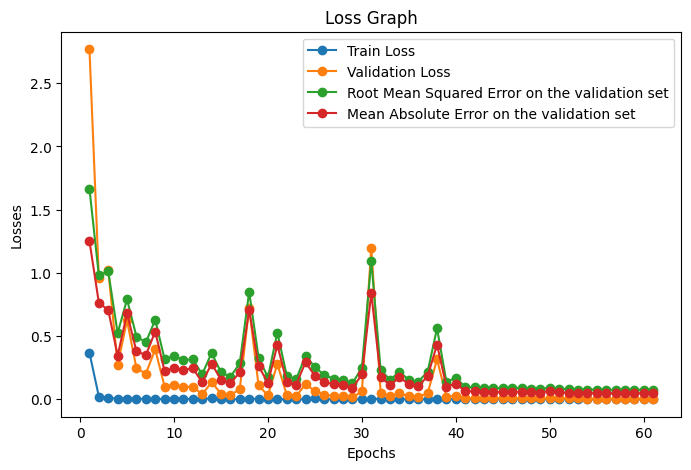

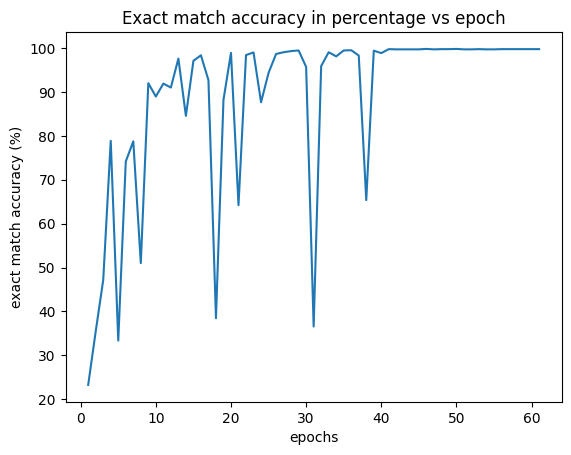

Reloaded best validation checkpoint from epoch 60


In [ ]:
cnn_normal_model_best = train(
    model=cnn_normal_model,
    x_train_data=x_train,
    y_train_data=y_train_normalized,
    optimizer=optimizer_normal,
    loss_fn=loss_fn_normal,
    normalized_coefficient=normalized_term,
    epochs=epochs,
    device=DEVICE,
    batch_size=batch_size,
    normalized_training=normalized_training,
    x_val_data=x_val,
    y_val_data=y_val_normalized,
    patience=20,
    min_delta=0.005,
)

#### 5.3.4 Save Best Model

In [ ]:
print("Best CNN custom loss checkpoint:")
print("Epoch:", cnn_normal_model_best["best_epoch"])
print("Validation accuracy:", cnn_normal_model_best["best_model_accuracy"])
print("Validation loss:", cnn_normal_model_best["best_model_loss"])
print("Validation RMSE:", cnn_normal_model_best["best_model_RMSE"])
print("Validation MAE:", cnn_normal_model_best["best_model_MAE"])

Best CNN custom loss checkpoint:
Epoch: 60
Validation accuracy: 99.75
Validation loss: 0.005505724810063839
Validation RMSE: 0.0742005705833435
Validation MAE: 0.046750783920288086


In [ ]:
model_to_save = cnn_normal_model
model_to_save.load_state_dict(cnn_normal_model_best["best_model_state"])

extra = {
    "val_accuracy": cnn_normal_model_best["best_model_accuracy"],
    "val_rmse": cnn_normal_model_best["best_model_RMSE"],
    "val_mae": cnn_normal_model_best["best_model_MAE"],
    "normalized_training": True,
}

save_cnn_checkpoint(
    model=model_to_save,
    optimizer=optimizer_normal,
    epoch=cnn_normal_model_best["best_epoch"],
    path=os.path.join(MODEL_DIR,"cnn_normal_model_best.pt"),
    loss=cnn_normal_model_best["best_model_loss"],
    extra=extra
)

Checkpoint saved to: /content/ML_Exam_Project/model/cnn_normal_model_best.pt


## 6 Testing the Regressors

In [ ]:
cnn_baseline_model,cnn_baseline_model_chkpt = load_cnn_checkpoint(os.path.join(MODEL_DIR,"cnn_baseline_model_best.pt"), DEVICE)

cnn_full_evaluation(model=cnn_baseline_model,
                    data=data,
                    normalized_training=False)

Loaded checkpoint from epoch 60
Train RMSE: 0.0502, MAE: 0.0358, Correct Matches: 11997 (99.97500000000001 %)
Validation RMSE: 0.2347, MAE: 0.0943, Correct Matches: 1952 (97.6 %)
Test ID RMSE: 0.3071, MAE: 0.1074, Correct Matches: 1944 (97.2 %)
Test OOD RMSE: 1.1808, MAE: 0.4703, Correct Matches: 1604 (80.2 %)
Test Long RMSE: 2.8766, MAE: 1.7340, Correct Matches: 517 (34.46666666666667 %)


In [ ]:
cnn_normal_model,cnn_normal_model_chkpt = load_cnn_checkpoint(os.path.join(MODEL_DIR,"cnn_normal_model_best.pt"), DEVICE)

cnn_full_evaluation(model=cnn_normal_model,
                    data=data,
                    normalized_training=True)

Loaded checkpoint from epoch 60
Train RMSE: 0.0421, MAE: 0.0315, Correct Matches: 12000 (100.0 %)
Validation RMSE: 0.0742, MAE: 0.0468, Correct Matches: 1995 (99.75 %)
Test ID RMSE: 0.0724, MAE: 0.0451, Correct Matches: 1996 (99.8 %)
Test OOD RMSE: 1.1965, MAE: 0.4305, Correct Matches: 1700 (85.0 %)
Test Long RMSE: 3.3913, MAE: 2.1687, Correct Matches: 553 (36.86666666666667 %)


#4. Trying to Improve Model Robustness with Fine-Tuning

### Loading the CNN checkpoint

This function is meant to load the trained CNN in another notebook without manually guessing the original setup.

The checkpoint contains both the trained weights and the information needed to reconstruct the model correctly.  
So instead of manually creating a new CNN and hoping that all hyperparameters match, we read the saved `model_config` from the checkpoint and rebuild the model from that.

The function also uses `map_location=device`, so the checkpoint can be loaded safely even if it was trained on GPU and later loaded on CPU, or vice versa.

After loading the weights, the model is set to `eval()` mode because this is the mode we want when using the saved model for validation, test predictions, or final evaluation. This is especially important if the architecture uses layers like dropout or batch normalization.

The function returns both:
- the reconstructed model, ready to use for predictions;
- the checkpoint dictionary, which still contains extra information such as epoch, validation metrics, vocabulary, padding token, and normalization values.

In [ ]:
# loaded_model, loaded_checkpoint = load_checkpoint(
#     "/content/cnn_regressor_best.pt",
#     DEVICE
# )

# train_augmented_df = load_jsonl(DATA_DIR / "train_augmented_C.jsonl")
# validation_augmented_df = load_jsonl(DATA_DIR / "validation_augmented_C.jsonl")

# train_augmented_df = apply_transformation(train_augmented_df)
# validation_augmented_df = apply_transformation(validation_augmented_df)

# x_train = train_augmented_df["expression"]
# x_val = validation_augmented_df["expression"]
# y_train_normalized = train_augmented_df["normalized_value"]
# y_val_normalized = validation_augmented_df["normalized_value"]

# optimizer_normal = torch.optim.Adam(loaded_model.parameters(), lr=learning_rate*0.1)
# normalized_training = True
# loss_fn_normalized = CustomExactMatchLoss(y_mean=y_mean,  y_std=y_std, alpha=1.0, beta=0.01, margin=0.5)

# cnn_custom_loss_best_refined = train(
#     model=loaded_model,
#     x_train_data=x_train,
#     y_train_data=y_train_normalized,
#     optimizer=optimizer_normal,
#     loss_fn=loss_fn_normalized,
#     normalized_coefficient=normalized_term,
#     epochs=epochs,
#     device=DEVICE,
#     batch_size=batch_size,
#     normalized_training=normalized_training,
#     x_val_data=x_val,
#     y_val_data=y_val_normalized,
#     patience=10,
#     min_delta=0.005,
# )

FileNotFoundError: [Errno 2] No such file or directory: '/content/cnn_regressor_best.pt'

#5. Model's Performances Analysis

#

The errors in the out of distributions test set can only be caused by the shift of the distribution itself; on the other hand, while evaluating on the long sequences test set, the errors that rise may be caused by different things: parenthesis depth, length of the sequences, operator counts and shift of distribution   

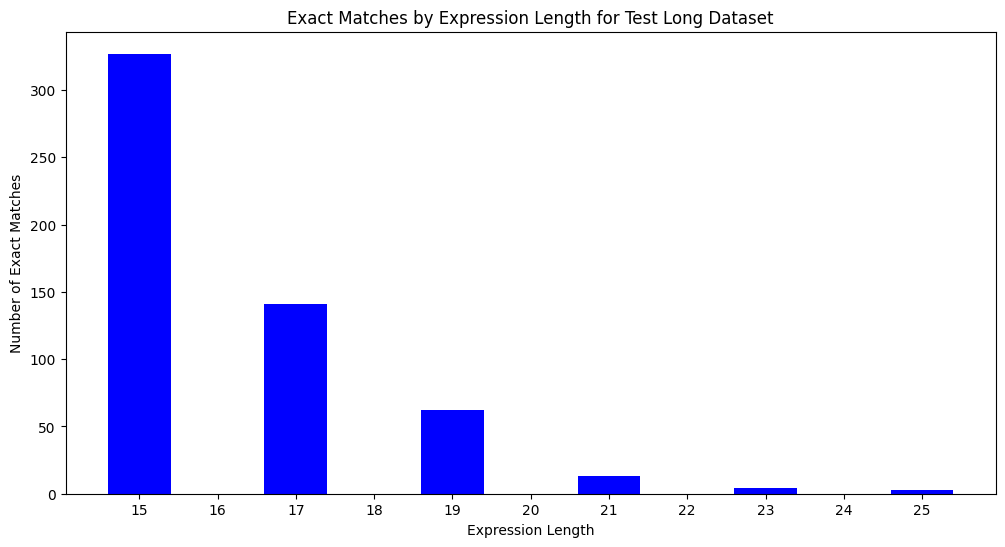

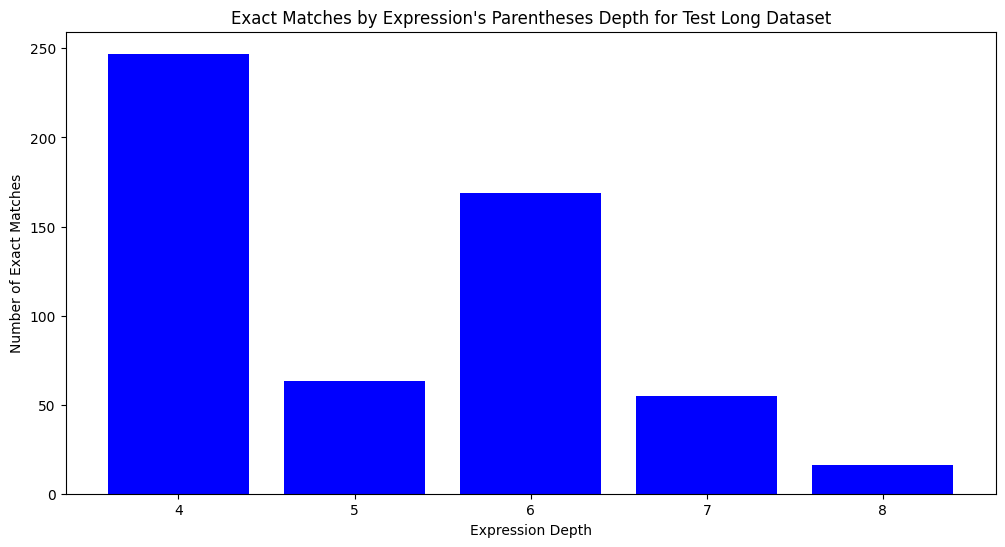

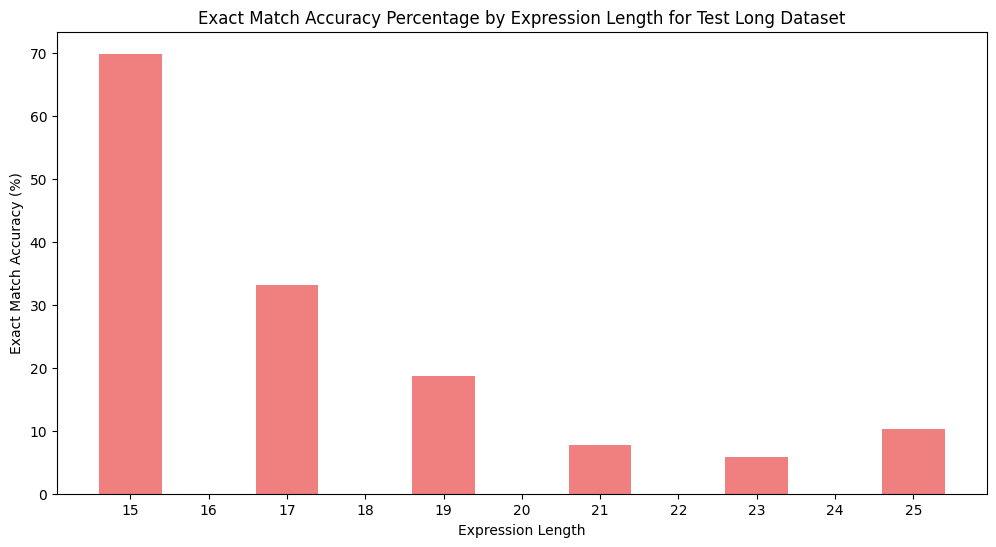

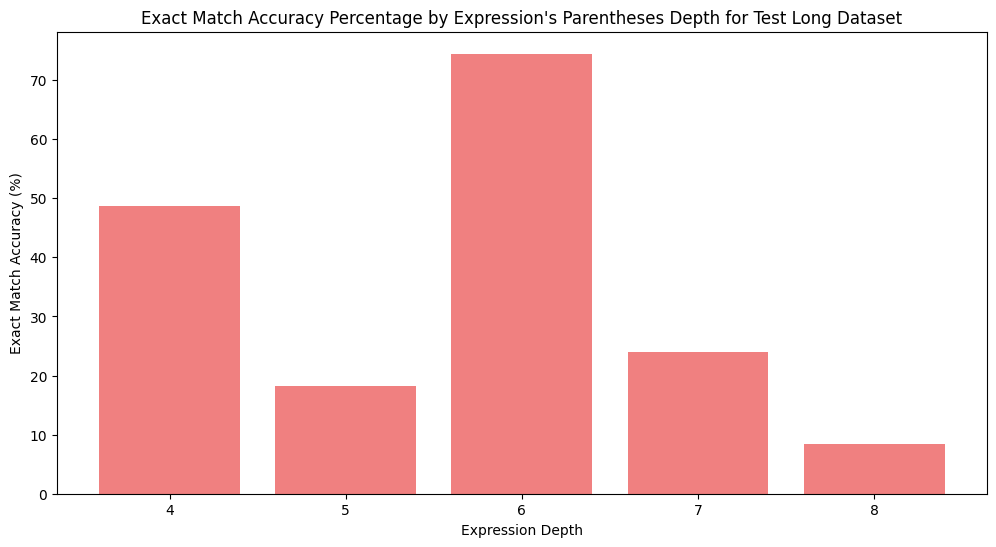

In [ ]:
predictions_diff = []
expression_lengths = [] # To store the length of each expression
exact_matches_by_length = {} # To store counts of exact matches for each length

expressions_depths = []
exact_matches_by_length_depths = {}


model_to_evaluate = cnn_normal_model #when we fix the file error we can put the enhanced one


model_to_evaluate.eval()


test_long_dataset_for_eval = list(zip(data["test_long"]["expression"], data["test_long"]["value"]))


test_long_loader_single_batch = torch.utils.data.DataLoader(
    test_long_dataset_for_eval,
    batch_size=1,
    shuffle=False, # Maintain order for plotting against index
    collate_fn=collate_fn
)

with torch.no_grad():
    for i, (x_batch, y_batch) in enumerate(test_long_loader_single_batch):
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)


        mask = (x_batch != token_to_index[PAD_TOKEN]).float()


        x_batch_one_hot = F.one_hot(x_batch, num_classes=VOCAB_SIZE).float().permute(0, 2, 1);


        y_pred_normalized = model_to_evaluate(x_batch_one_hot, mask)

        #we are using normalized targets for the training
        y_pred_denormalized = denormalize_target_value(y_pred_normalized, y_mean, y_std)    #this might cause an error!!!

        # .squeeze(0) is used because batch_size=1, so y_pred_denormalized is a 1-element tensor.
        pred_rounded = torch.round(y_pred_denormalized.squeeze(0)).item()
        target_rounded = torch.round(y_batch.squeeze(0)).item()

        diff = pred_rounded - target_rounded
        predictions_diff.append(diff)

        # Get original expression length
        length = data["test_long"]['length'][i]
        expression_lengths.append(length)
        # Get original expression parenthesis depth
        parenthesis_depth = data["test_long"]['depth'][i]
        expressions_depths.append(parenthesis_depth)

        # Check for exact match and store for histogram
        if diff == 0:
            exact_matches_by_length[length] = exact_matches_by_length.get(length, 0) + 1
            exact_matches_by_length_depths[parenthesis_depth] = exact_matches_by_length_depths.get(parenthesis_depth, 0) + 1


# Create a DataFrame for easier plotting
plot_data_lengths = pd.DataFrame({"Expression Length": expression_lengths, "Prediction Error": predictions_diff})

plot_data_depths = pd.DataFrame({"Expression Depth": expressions_depths, "Prediction Error": predictions_diff})




# Plotting exact match accuracy by expression length

lengths = sorted(exact_matches_by_length.keys())
exact_match_counts = [exact_matches_by_length[l] for l in lengths]



depths = sorted(exact_matches_by_length_depths.keys())
exact_match_counts_depths = [exact_matches_by_length_depths[l] for l in depths]

plt.figure(figsize=(12, 6))
plt.bar(lengths, exact_match_counts, color="blue")
plt.title("Exact Matches by Expression Length for Test Long Dataset")
plt.xlabel("Expression Length")
plt.ylabel("Number of Exact Matches")
plt.xticks(range(min(lengths), max(lengths) + 1))
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(depths, exact_match_counts_depths, color="blue")
plt.title("Exact Matches by Expression's Parentheses Depth for Test Long Dataset")
plt.xlabel("Expression Depth")
plt.ylabel("Number of Exact Matches")
plt.xticks(range(min(depths), max(depths) + 1))
plt.show()

# Plot exact match percentage by length if we also count total for each length
total_samples_by_length = plot_data_lengths["Expression Length"].value_counts().sort_index()      #value_counts for counting one time every length that there is (after this the total_samples becomes (length, number of expressions with that length)), sort_index to put it in ascending order
total_samples_by_depth = plot_data_depths["Expression Depth"].value_counts().sort_index()
exact_match_percentages_length = {}
exact_match_percentages_depth = {}
for length in lengths:
    if length in total_samples_by_length and total_samples_by_length[length] > 0:
        percentage = (exact_matches_by_length.get(length, 0) / total_samples_by_length[length]) * 100     #get(length, 0) because if it doesn't find length, it returns 0
        exact_match_percentages_length[length] = percentage

for depth in depths:
    if depth in total_samples_by_depth and total_samples_by_depth[depth] > 0:
        percentage = (exact_matches_by_length_depths.get(depth, 0) / total_samples_by_depth[depth]) * 100
        exact_match_percentages_depth[depth] = percentage

if exact_match_percentages_length:
    plt.figure(figsize=(12, 6))
    plt.bar(list(exact_match_percentages_length.keys()), list(exact_match_percentages_length.values()), color="lightcoral") # Changed from sns.barplot
    plt.title("Exact Match Accuracy Percentage by Expression Length for Test Long Dataset")
    plt.xlabel("Expression Length")
    plt.ylabel("Exact Match Accuracy (%)")
    plt.xticks(range(min(lengths), max(lengths) + 1))
    plt.show()

if exact_match_percentages_depth:
    plt.figure(figsize=(12, 6))
    plt.bar(list(exact_match_percentages_depth.keys()), list(exact_match_percentages_depth.values()), color="lightcoral")
    plt.title("Exact Match Accuracy Percentage by Expression's Parentheses Depth for Test Long Dataset")
    plt.xlabel("Expression Depth")
    plt.ylabel("Exact Match Accuracy (%)")
    plt.xticks(range(min(depths), max(depths) + 1))
    plt.show()

In [ ]:
def run_transformer_predictor(input_df, device, model, batch_size=128):
  if not isinstance(input_df, pd.DataFrame):
      raise TypeError("Input must be a single pandas DataFrame.")

  predictions = []
  exact_match = []

  # Prepare target labels (shifted by +99 for classification)
  y_labels = input_df["value"]
  expressions = input_df["expression"]

  # Create a DataLoader using the existing make_loader function
  loader = make_loader(expressions, y_labels, batch_size=batch_size)

  model.eval() # Set model to evaluation mode
  with torch.no_grad(): # Disable gradient calculations
      for x_batch, y_batch_classification in loader:
          x_batch = x_batch.to(device)
          y_batch = y_batch.to(device)

          mask = (x_batch != token_to_index[PAD_TOKEN])
          y_pred = model(x_batch, mask)


          real_y_pred = round(y_pred)
          real_y_batch = round(y_batch)

          # Compare rounded predictions to true values

          for i in range(len(real_y_pred)):
              predictions.append(real_y_pred[i])
              if real_y_pred[i] == real_y_true[i]:
                  exact_match.append(True)
              else:
                  exact_match.append(False)

  # Create a copy of the input DataFrame and add the new columns
  output_df = input_df.copy()
  output_df['prediction'] = predictions
  output_df['exact_match'] = exact_match
  return output_df